In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [2]:
df = pd.read_csv("../data/heart_disease_uci.csv")
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded successfully with 920 rows and 16 columns


## 2. Initial Data Overview

In [6]:
# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (920, 16)

Column Names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [7]:
# First few rows
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [33]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3+ KB


## 3. Target Variable Analysis & Creation

In [8]:
# Examine original target variable
print("Original 'num' variable distribution:")
print(df['num'].value_counts().sort_index())
print("\nProportions:")
print(df['num'].value_counts(normalize=True).sort_index())

Original 'num' variable distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Proportions:
num
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64


In [9]:
# Create binary target variable
# 0 = No disease, 1 = Disease present (any severity)
df['target'] = (df['num'] > 0).astype(int)

print("Binary 'target' variable distribution:")
print(df['target'].value_counts())
print("\nProportions:")
print(df['target'].value_counts(normalize=True))

Binary 'target' variable distribution:
target
1    509
0    411
Name: count, dtype: int64

Proportions:
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


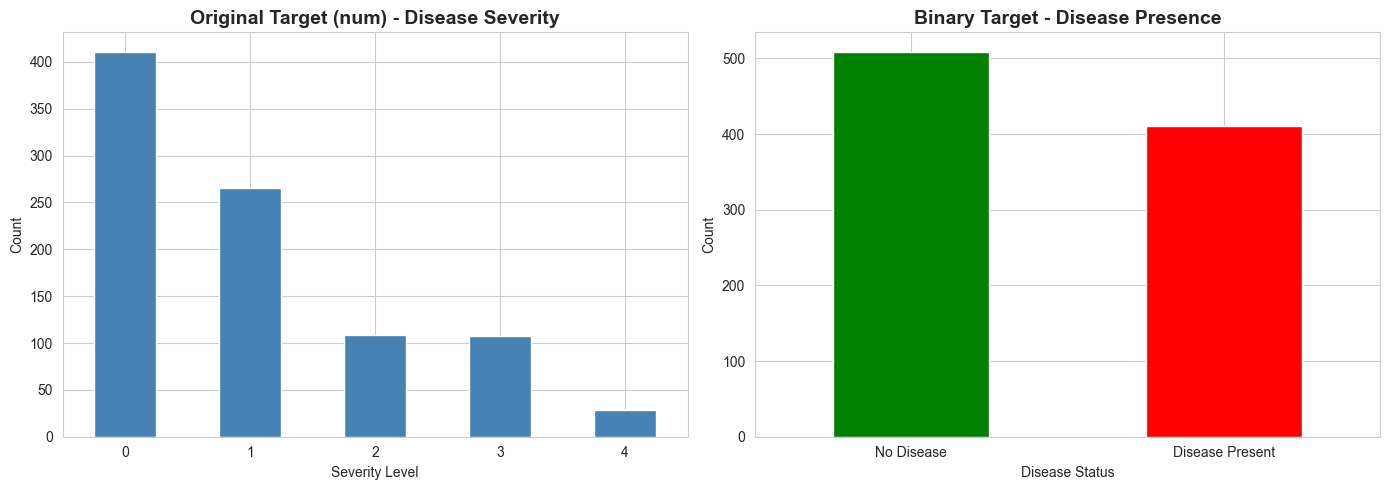


⚠️ Class Balance: 55.3% disease cases


In [10]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original target
df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original Target (num) - Disease Severity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Binary target
df['target'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Binary Target - Disease Presence', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Disease Status')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Disease', 'Disease Present'], rotation=0)

plt.tight_layout()
plt.show()

print(f"\n⚠️ Class Balance: {df['target'].value_counts(normalize=True)[1]:.1%} disease cases")

**Key Insight:** The original target variable `num` represents heart disease severity from 0 to 4. We've converted it into a binary variable `target`, where 1 indicates presence of heart disease (any severity) and 0 indicates no disease.

## 4. Missing Values Analysis

In [11]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

missing_data = missing_data[missing_data['Missing_Count'] > 0]

print("Missing Values Summary:")
print(missing_data)
print(f"\nTotal columns with missing values: {len(missing_data)}")

Missing Values Summary:
          Missing_Count  Missing_Percentage
ca                  611               66.41
thal                486               52.83
slope               309               33.59
fbs                  90                9.78
oldpeak              62                6.74
trestbps             59                6.41
exang                55                5.98
thalch               55                5.98
chol                 30                3.26
restecg               2                0.22

Total columns with missing values: 10


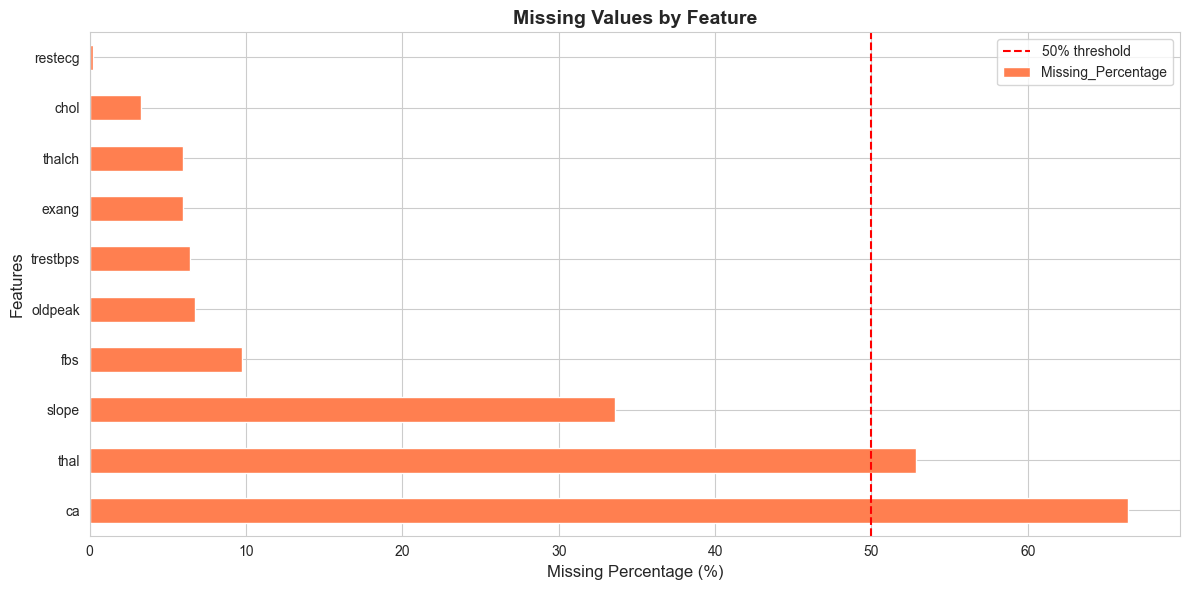

In [12]:
# Visualize missing values
if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_data['Missing_Percentage'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Percentage (%)', fontsize=12)
    ax.set_ylabel('Features', fontsize=12)
    ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', label='50% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

**Key Insight:** Features like `ca`, `thal`, and `slope` have substantial missing data (>30%). These will require careful preprocessing - consider imputation vs. deletion strategies based on model requirements.

## 5. Data Quality Checks

In [13]:
# Check for suspicious zero values in numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop(['id', 'num', 'target'])

print("Checking for suspicious zero/invalid values:\n")
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df) * 100)
    if zero_count > 0:
        print(f"{col}: {zero_count} zeros ({zero_pct:.1f}%)")
        print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
        print()

Checking for suspicious zero/invalid values:

trestbps: 1 zeros (0.1%)
  Min: 0.0, Max: 200.0

chol: 172 zeros (18.7%)
  Min: 0.0, Max: 603.0

oldpeak: 370 zeros (40.2%)
  Min: -2.6, Max: 6.2

ca: 181 zeros (19.7%)
  Min: 0.0, Max: 3.0



In [15]:
# Check for medically invalid values
print("Data Quality Issues Detected:\n")

# Negative oldpeak (should be non-negative)
if 'oldpeak' in df.columns:
    negative_oldpeak = (df['oldpeak'] < 0).sum()
    print(f"⚠️ oldpeak: {negative_oldpeak} negative values (medically invalid)")
    print(f"   Range: {df['oldpeak'].min()} to {df['oldpeak'].max()}\n")

# Unrealistic blood pressure (trestbps should be > 0)
if 'trestbps' in df.columns:
    invalid_bp = (df['trestbps'] == 0).sum()
    print(f"⚠️ trestbps: {invalid_bp} zero values (likely missing, not actual zeros)")
    print(f"   These should probably be treated as missing values\n")

# Zero cholesterol (chol should be > 0)
if 'chol' in df.columns:
    invalid_chol = (df['chol'] == 0).sum()
    print(f"⚠️ chol: {invalid_chol} zero values (likely missing, not actual zeros)")

Data Quality Issues Detected:

⚠️ oldpeak: 12 negative values (medically invalid)
   Range: -2.6 to 6.2

⚠️ trestbps: 1 zero values (likely missing, not actual zeros)
   These should probably be treated as missing values

⚠️ chol: 172 zero values (likely missing, not actual zeros)


**Critical Finding:** Multiple features contain 0.0 values that likely represent missing data rather than true zeros. These should be converted to NaN during preprocessing.

## 6. Statistical Summary

In [16]:
# Descriptive statistics for numerical features
df.describe().T.style.background_gradient(cmap='YlOrRd')

,count,mean,std,min,25%,50%,75%,max
id,920.000000,460.500000,265.725422,1.000000,230.750000,460.500000,690.250000,920.000000
age,920.000000,53.510870,9.424685,28.000000,47.000000,54.000000,60.000000,77.000000
trestbps,861.000000,132.132404,19.066070,0.000000,120.000000,130.000000,140.000000,200.000000
chol,890.000000,199.130337,110.780810,0.000000,175.000000,223.000000,268.000000,603.000000
thalch,865.000000,137.545665,25.926276,60.000000,120.000000,140.000000,157.000000,202.000000
oldpeak,858.000000,0.878788,1.091226,-2.600000,0.000000,0.500000,1.500000,6.200000
ca,309.000000,0.676375,0.935653,0.000000,0.000000,0.000000,1.000000,3.000000
num,920.000000,0.995652,1.142693,0.000000,0.000000,1.000000,2.000000,4.000000
target,920.000000,0.553261,0.497426,0.000000,0.000000,1.000000,1.000000,1.000000


In [17]:
# Detailed statistics by target class
print("Statistics by Disease Status:\n")
for col in numerical_cols:
    print(f"\n{col.upper()}:")
    print(df.groupby('target')[col].describe()[['mean', 'std', 'min', 'max']].round(2))

Statistics by Disease Status:


AGE:
         mean   std   min   max
target                         
0       50.55  9.43  28.0  76.0
1       55.90  8.72  31.0  77.0

TRESTBPS:
          mean    std   min    max
target                            
0       129.91  16.87  80.0  190.0
1       133.98  20.55   0.0  200.0

CHOL:
          mean     std  min    max
target                            
0       227.91   75.83  0.0  564.0
1       176.48  127.52  0.0  603.0

THALCH:
          mean    std   min    max
target                            
0       148.80  23.61  69.0  202.0
1       128.26  24.02  60.0  195.0

OLDPEAK:
        mean   std  min  max
target                      
0       0.42  0.72 -1.1  4.2
1       1.26  1.20 -2.6  6.2

CA:
        mean   std  min  max
target                      
0       0.28  0.64  0.0  3.0
1       1.13  1.01  0.0  3.0


## 7. Categorical Variables Analysis

In [18]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical features: {categorical_cols}\n")

# Value counts for each categorical variable
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

Categorical features: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


SEX:
sex
Male      726
Female    194
Name: count, dtype: int64
Unique values: 2

DATASET:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64
Unique values: 4

CP:
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64
Unique values: 4

FBS:
fbs
False    692
True     138
Name: count, dtype: int64
Unique values: 2

RESTECG:
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64
Unique values: 3

EXANG:
exang
False    528
True     337
Name: count, dtype: int64
Unique values: 2

SLOPE:
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64
Unique values: 3

THAL:
thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64
Unique values: 3


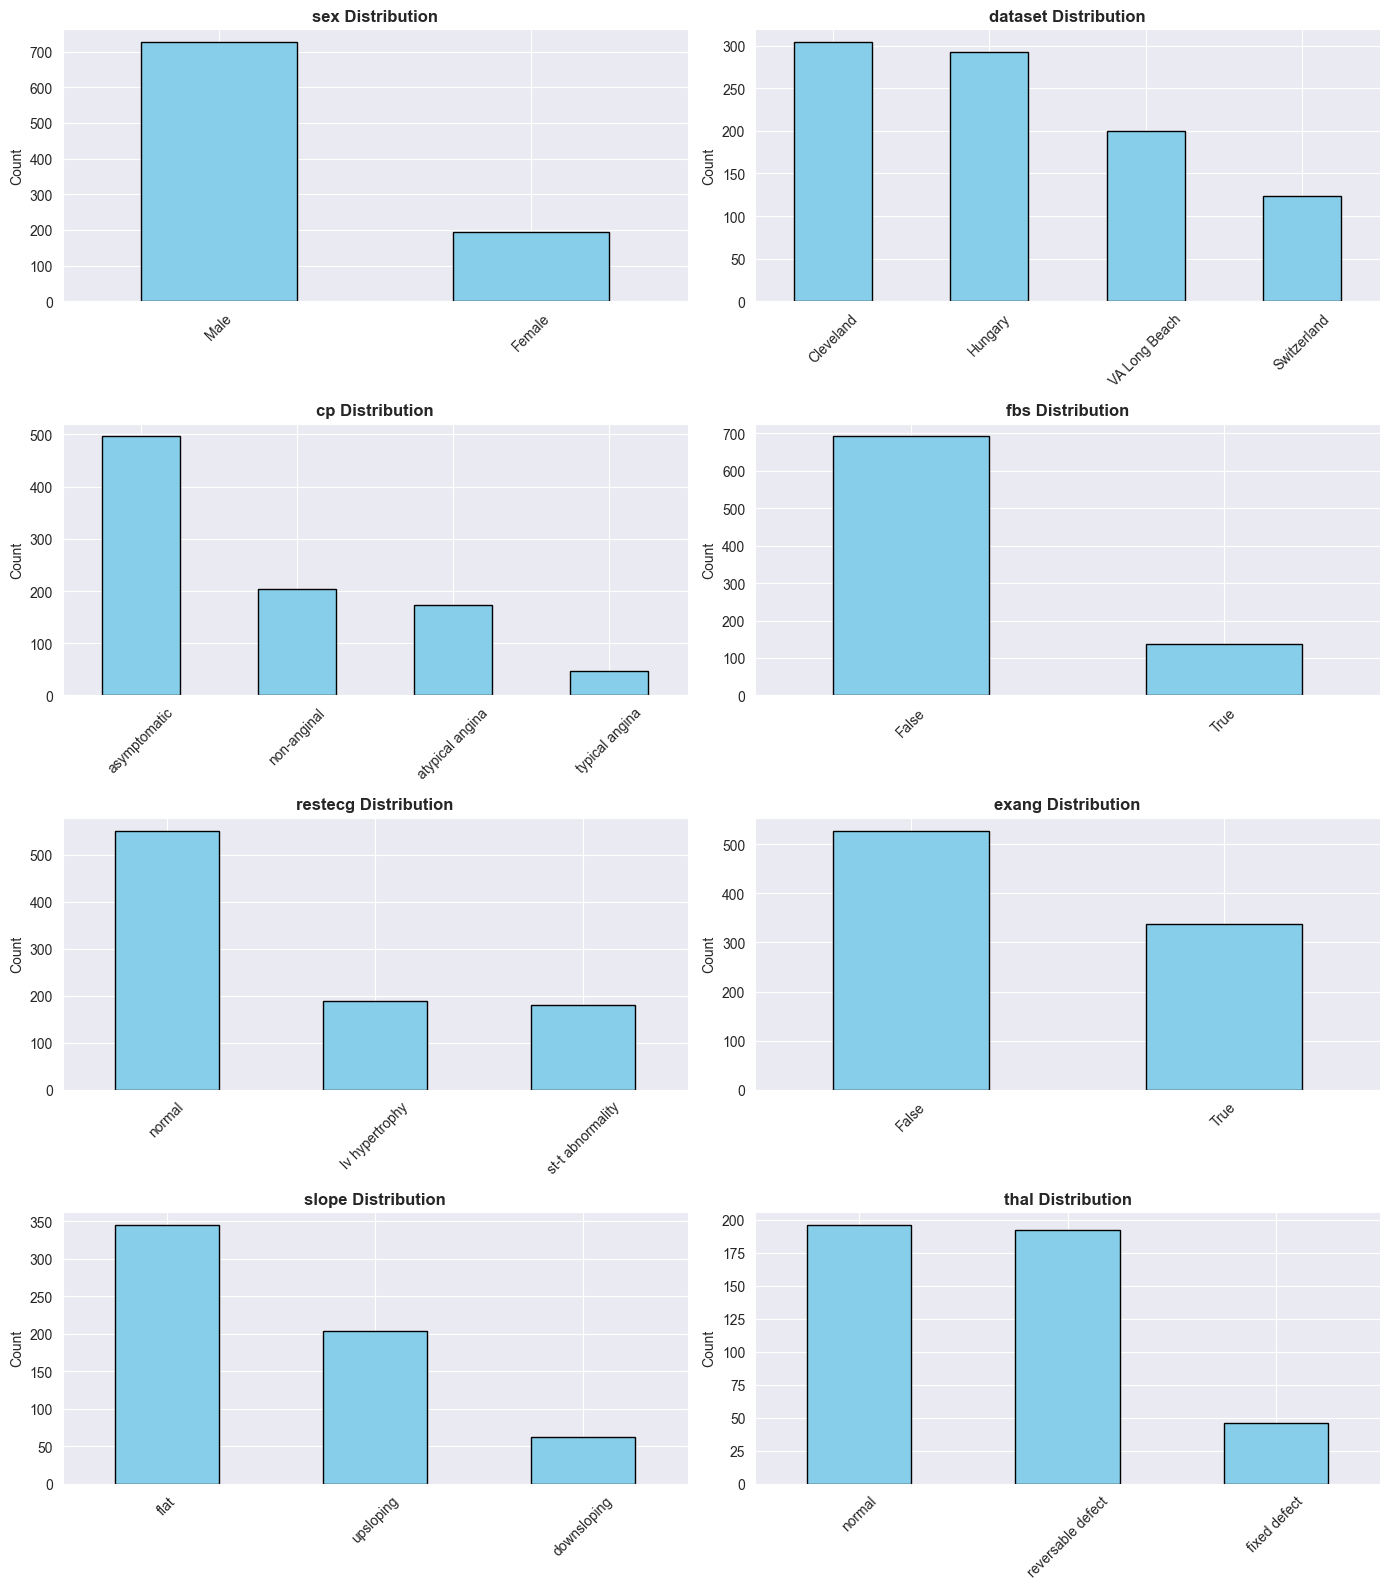

In [19]:
# Visualize categorical distributions
n_cat = len(categorical_cols)
if n_cat > 0:
    fig, axes = plt.subplots(nrows=(n_cat + 1) // 2, ncols=2, figsize=(14, 4 * ((n_cat + 1) // 2)))
    axes = axes.flatten() if n_cat > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide extra subplots if odd number of categories
    if n_cat % 2 != 0:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 8. Numerical Features Distribution

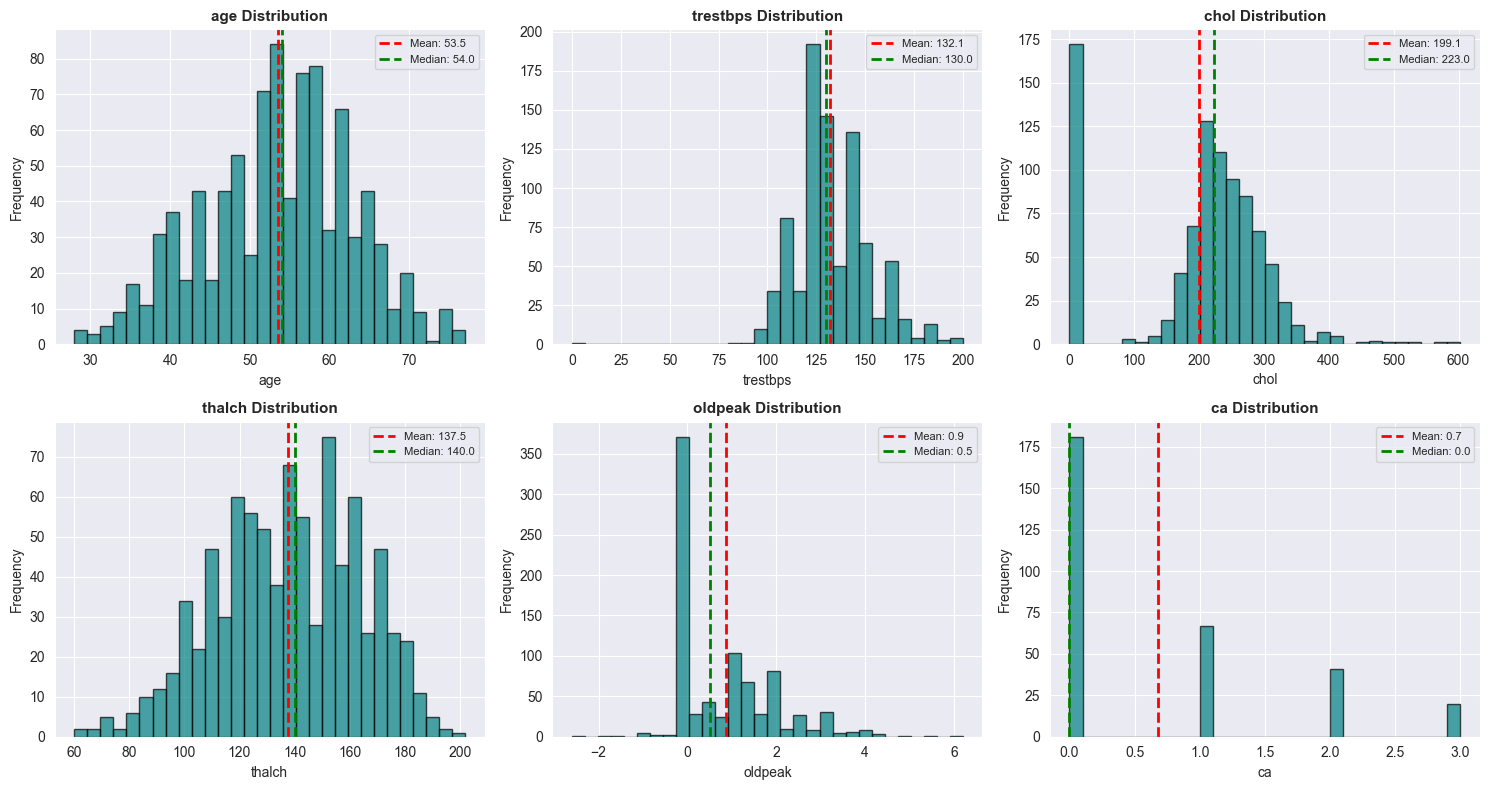

In [22]:
# Distribution plots for numerical features
n_num = len(numerical_cols)
fig, axes = plt.subplots(nrows=(n_num + 2) // 3, ncols=3, figsize=(15, 4 * ((n_num + 2) // 3)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Remove zeros for visualization if they're likely missing values
    data = df[col].dropna()
    
    axes[idx].hist(data, bins=30, color='teal', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.1f}')
    axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.1f}')
    axes[idx].legend(fontsize=8)

# Hide extra subplots
for idx in range(n_num, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

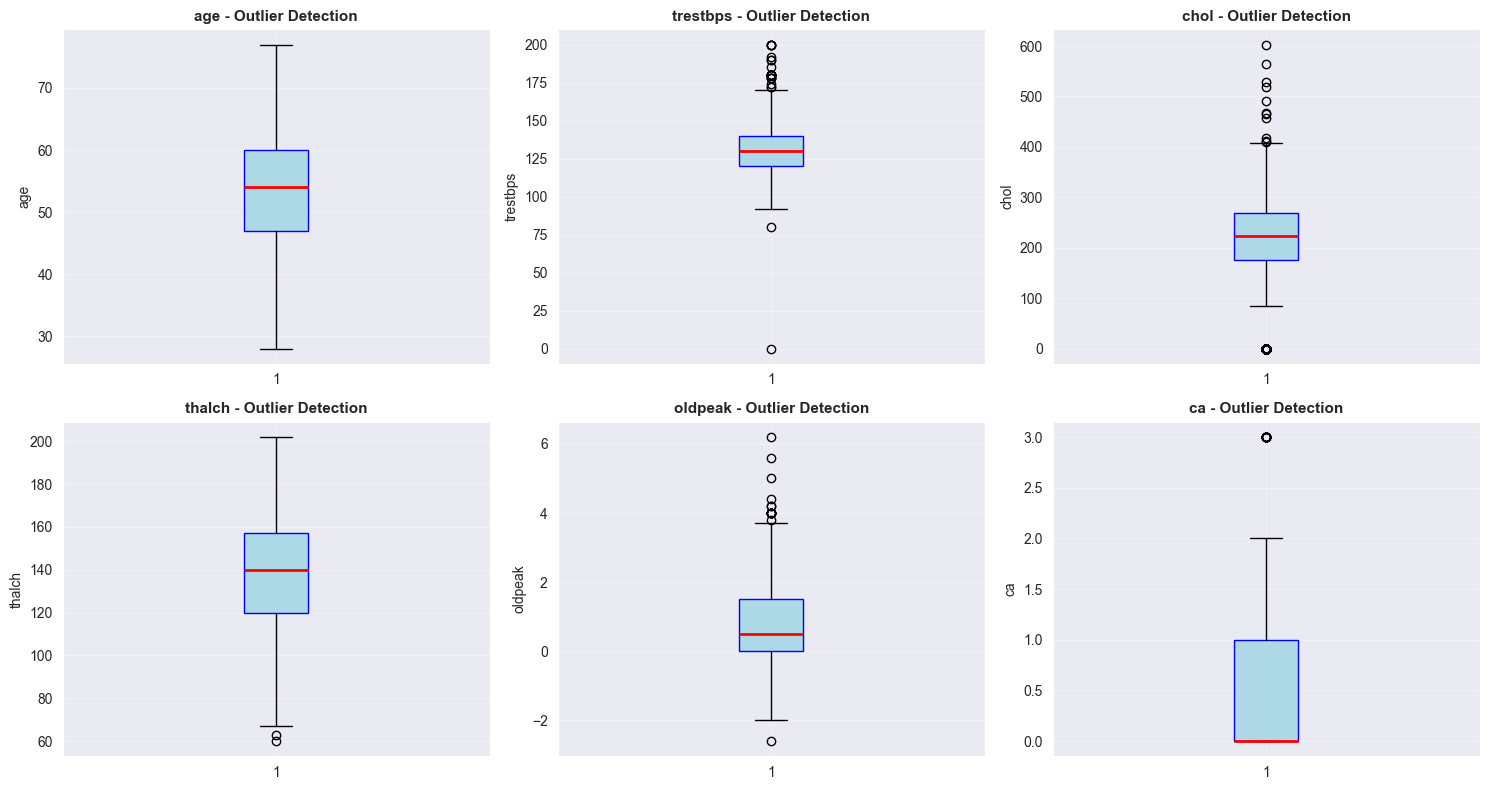

In [23]:
# Box plots to identify outliers
fig, axes = plt.subplots(nrows=(n_num + 2) // 3, ncols=3, figsize=(15, 4 * ((n_num + 2) // 3)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    data = df[col].dropna()
    axes[idx].boxplot(data, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='blue'),
                     medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{col} - Outlier Detection', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

# Hide extra subplots
#for idx in range(n_num, len(axes)):
    #axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Outlier Detection (Statistical)

In [24]:
# Detect outliers using IQR method
print("Outlier Detection (IQR Method):\n")

outlier_summary = {}
for col in numerical_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_summary[col] = len(outliers)
    
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
        print(f"  Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outlier values: {sorted(outliers.unique())[:10]}...\n" if len(outliers.unique()) > 10 else f"  Outlier values: {sorted(outliers.unique())}\n")

Outlier Detection (IQR Method):

trestbps: 28 outliers (3.3%)
  Range: [90.00, 170.00]
  Outlier values: [np.float64(0.0), np.float64(80.0), np.float64(172.0), np.float64(174.0), np.float64(178.0), np.float64(180.0), np.float64(185.0), np.float64(190.0), np.float64(192.0), np.float64(200.0)]

chol: 183 outliers (20.6%)
  Range: [35.50, 407.50]
  Outlier values: [np.float64(0.0), np.float64(409.0), np.float64(412.0), np.float64(417.0), np.float64(458.0), np.float64(466.0), np.float64(468.0), np.float64(491.0), np.float64(518.0), np.float64(529.0)]...

thalch: 2 outliers (0.2%)
  Range: [64.50, 212.50]
  Outlier values: [np.float64(60.0), np.float64(63.0)]

oldpeak: 16 outliers (1.9%)
  Range: [-2.25, 3.75]
  Outlier values: [np.float64(-2.6), np.float64(3.8), np.float64(4.0), np.float64(4.2), np.float64(4.4), np.float64(5.0), np.float64(5.6), np.float64(6.2)]

ca: 20 outliers (6.5%)
  Range: [-1.50, 2.50]
  Outlier values: [np.float64(3.0)]



## 10. Correlation Analysis

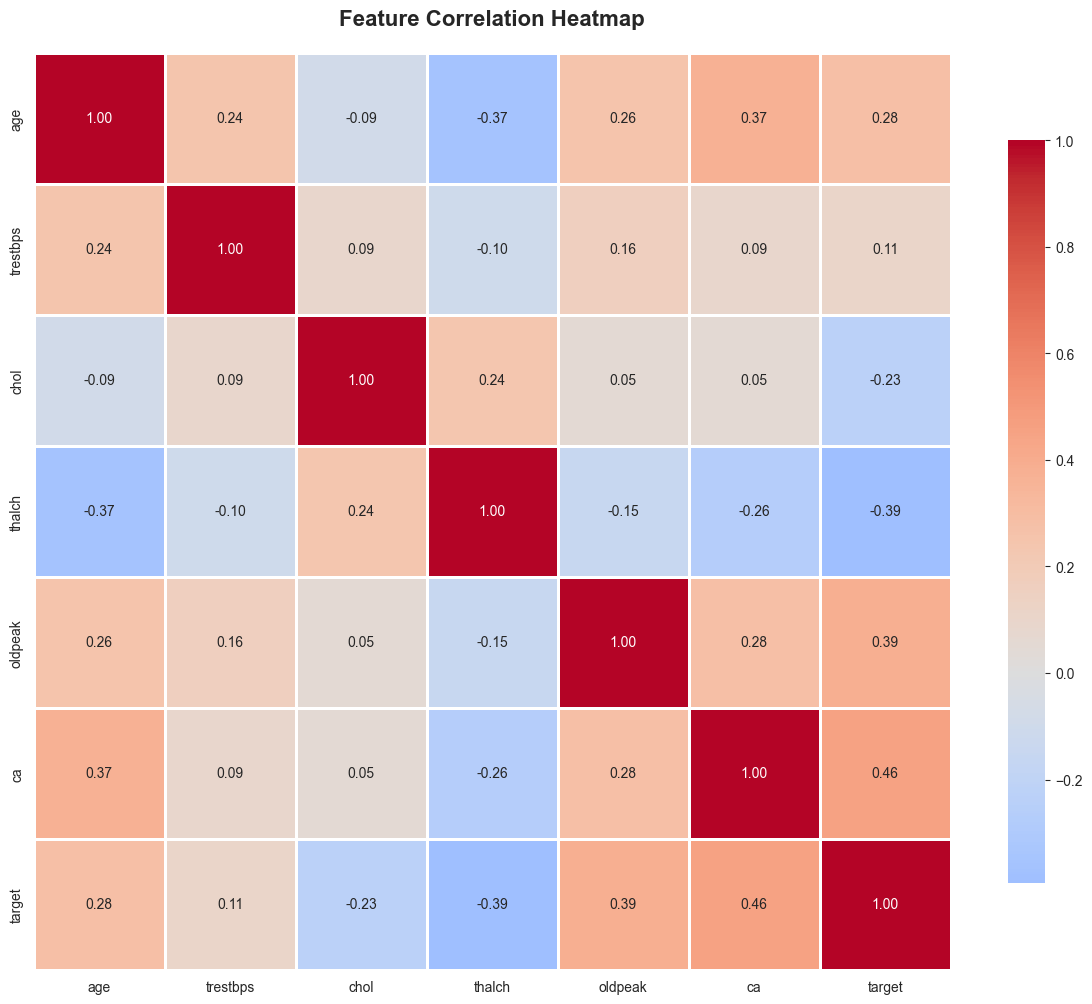

In [26]:
# Correlation matrix for numerical features
correlation_matrix = df[list(numerical_cols) + ['target']].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Correlation with Target Variable (Disease Presence):

ca          0.455599
oldpeak     0.385528
age         0.282700
trestbps    0.106233
chol       -0.230583
thalch     -0.394503
Name: target, dtype: float64


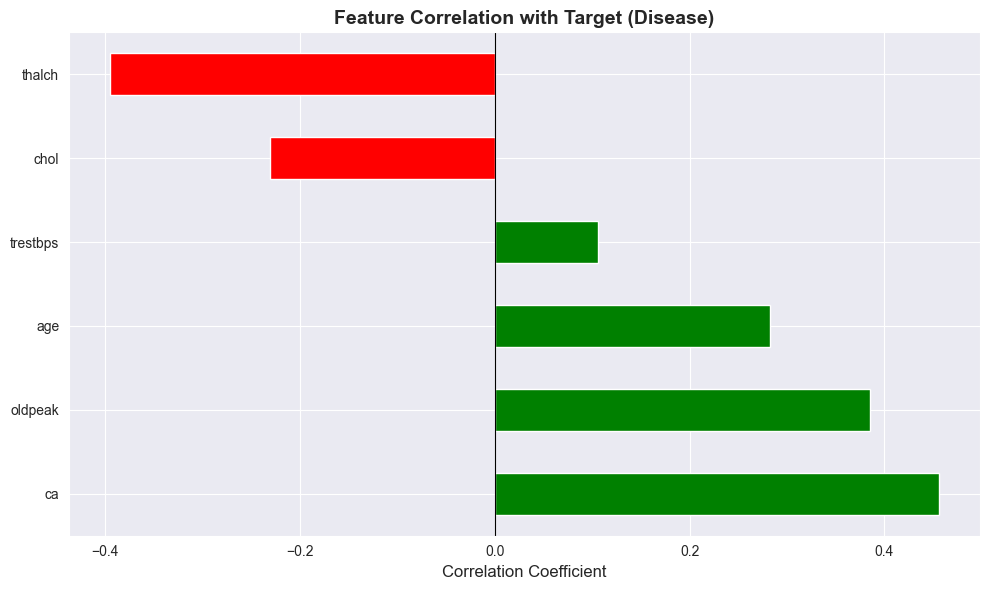

In [28]:
# Correlation with target variable
target_corr = correlation_matrix['target'].drop('target').sort_values(ascending=False)

print("Correlation with Target Variable (Disease Presence):\n")
print(target_corr)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
target_corr.plot(kind='barh', ax=ax, color=['green' if x > 0 else 'red' for x in target_corr])
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlation with Target (Disease)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

## 11. Bivariate Analysis - Features vs Target

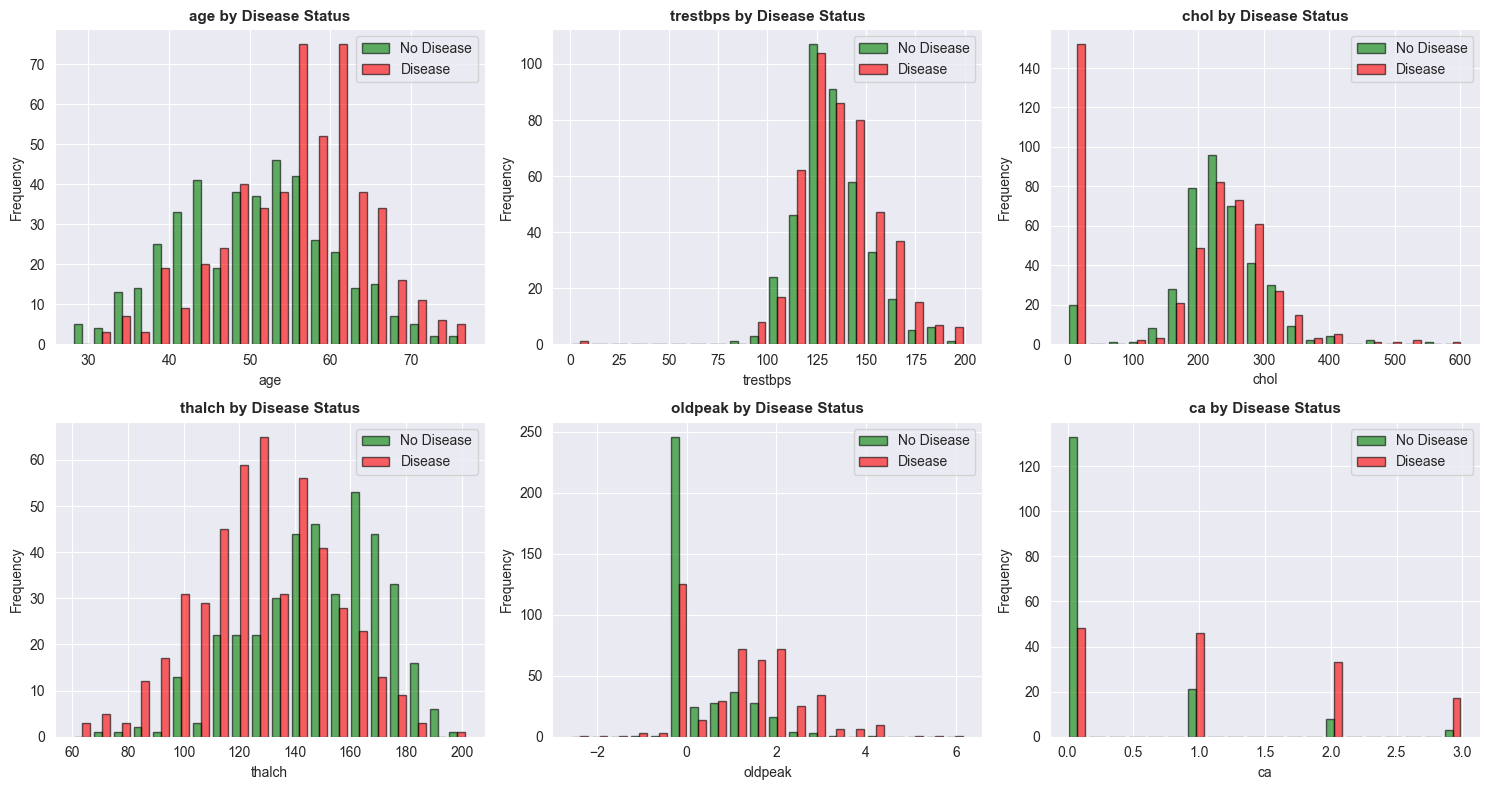

In [29]:
# Distribution of numerical features by target class
fig, axes = plt.subplots(nrows=(n_num + 2) // 3, ncols=3, figsize=(15, 4 * ((n_num + 2) // 3)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Separate data by target class
    no_disease = df[df['target'] == 0][col].dropna()
    disease = df[df['target'] == 1][col].dropna()
    
    axes[idx].hist([no_disease, disease], bins=20, label=['No Disease', 'Disease'], 
                   color=['green', 'red'], alpha=0.6, edgecolor='black')
    axes[idx].set_title(f'{col} by Disease Status', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

# Hide extra subplots
for idx in range(n_num, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

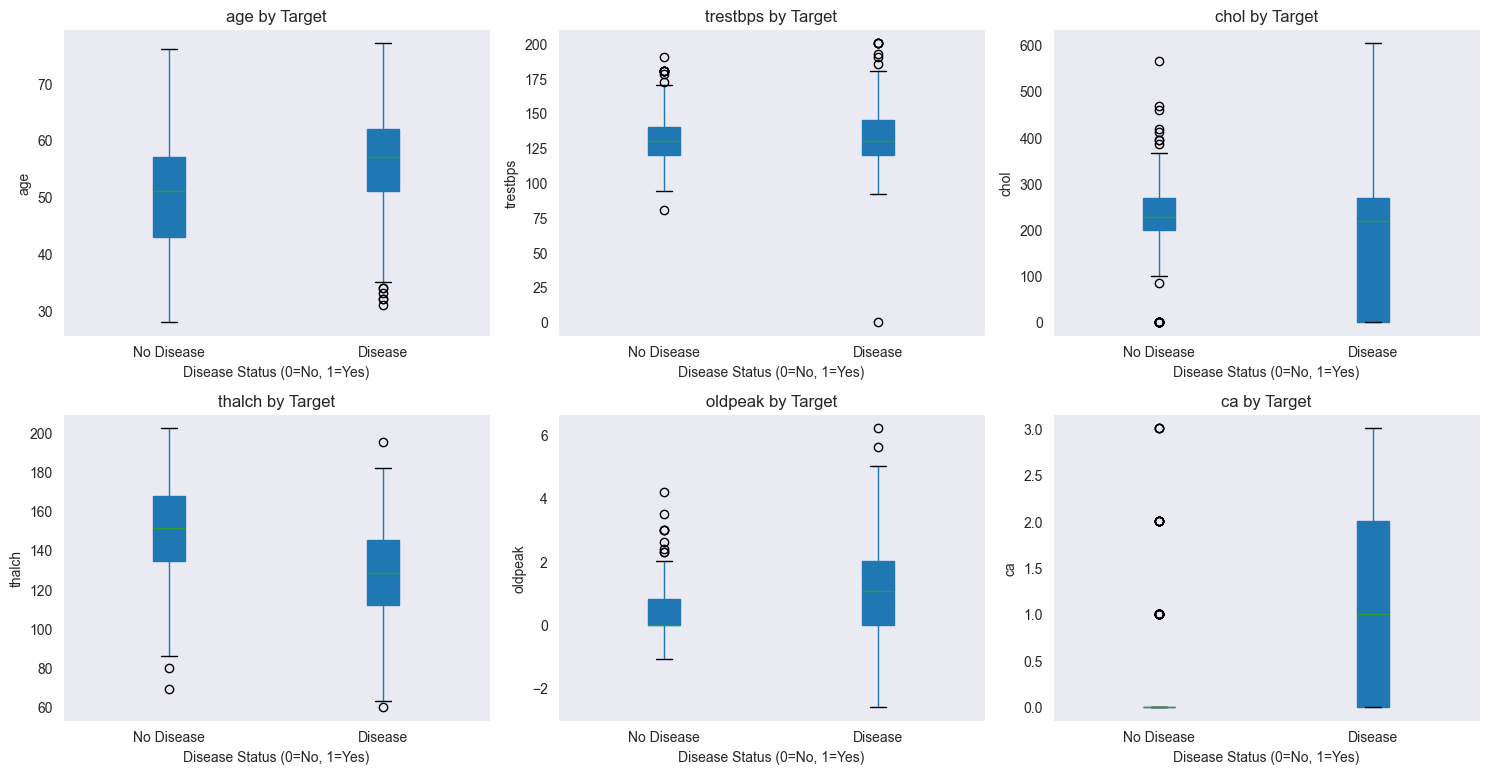

In [32]:
# Box plots: numerical features by target
fig, axes = plt.subplots(nrows=(n_num + 2) // 3, ncols=3, figsize=(15, 4 * ((n_num + 2) // 3)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    df_plot = df[[col, 'target']].dropna()
    df_plot.boxplot(column=col, by='target', ax=axes[idx], 
                   patch_artist=True, grid=False)
    axes[idx].set_title(f'{col} by Target')
    axes[idx].set_xlabel('Disease Status (0=No, 1=Yes)')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['No Disease', 'Disease'])

# Hide extra subplots
for idx in range(n_num, len(axes)):
   axes[idx].set_visible(False)

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()

## 12. Categorical Features vs Target

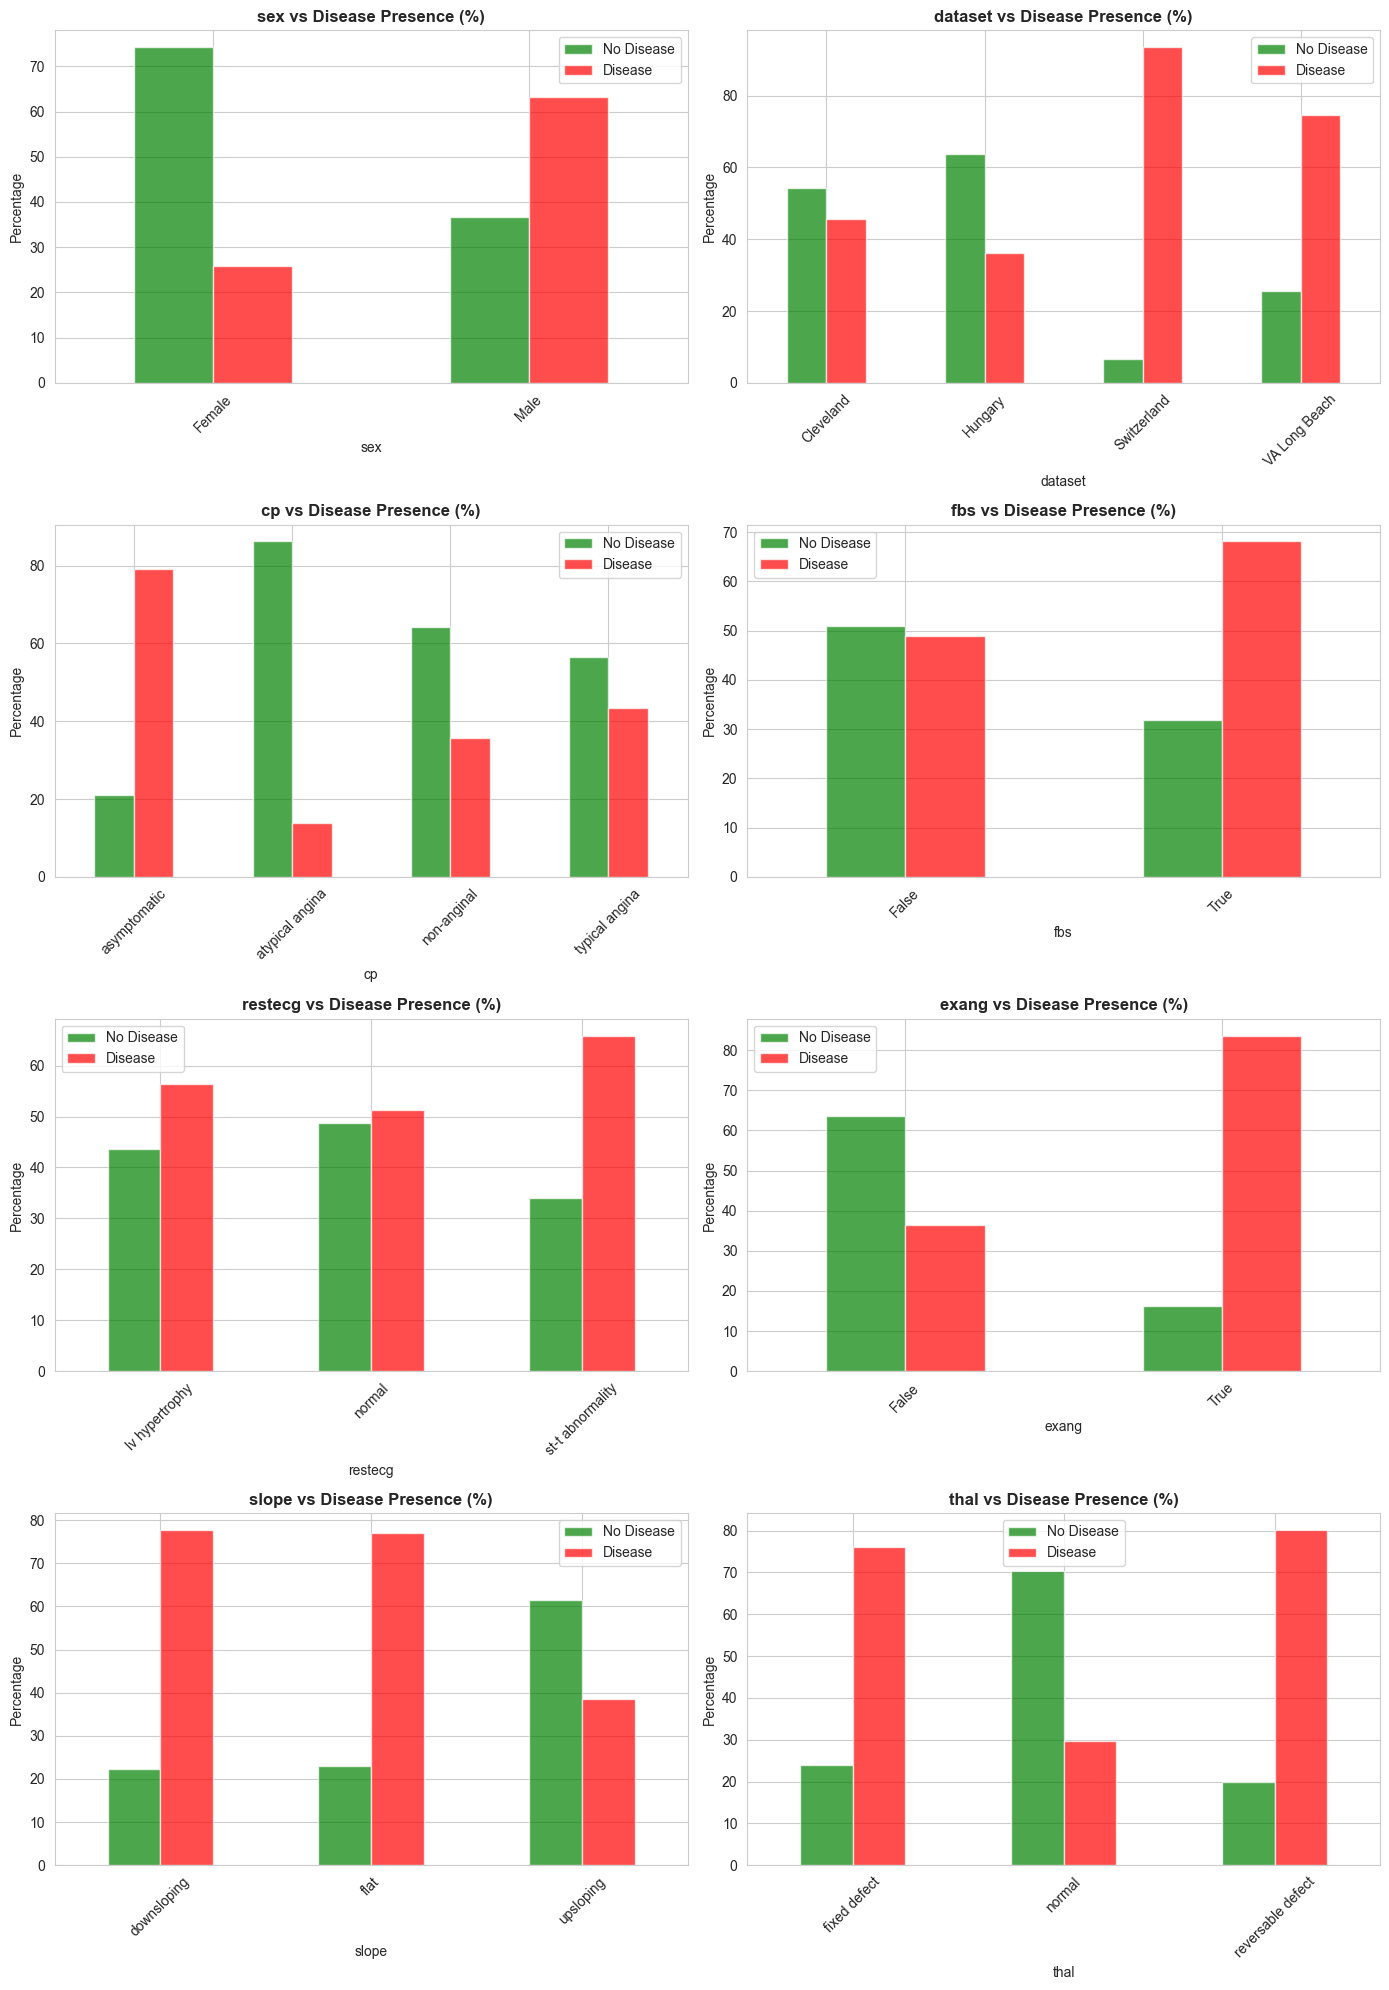

In [24]:
# Analyze categorical variables with respect to target
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(nrows=(len(categorical_cols) + 1) // 2, ncols=2, 
                            figsize=(14, 5 * ((len(categorical_cols) + 1) // 2)))
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        # Cross-tabulation
        ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
        ct.plot(kind='bar', stacked=False, ax=axes[idx], color=['green', 'red'], alpha=0.7)
        axes[idx].set_title(f'{col} vs Disease Presence (%)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage')
        axes[idx].legend(['No Disease', 'Disease'], loc='best')
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide extra subplot if odd number
    if len(categorical_cols) % 2 != 0:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [26]:
# Statistical relationship testing (Chi-square for categorical variables)
from scipy.stats import chi2_contingency

print("Chi-Square Test Results (Categorical Features vs Target):\n")
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['target'])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    print(f"{col}:")
    print(f"  Chi-square statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Significant: {'Yes ✓' if p_value < 0.05 else 'No ✗'}\n")

Chi-Square Test Results (Categorical Features vs Target):

sex:
  Chi-square statistic: 85.3612
  P-value: 0.0000
  Significant: Yes ✓

dataset:
  Chi-square statistic: 157.0605
  P-value: 0.0000
  Significant: Yes ✓

cp:
  Chi-square statistic: 268.3457
  P-value: 0.0000
  Significant: Yes ✓

fbs:
  Chi-square statistic: 16.1116
  P-value: 0.0001
  Significant: Yes ✓

restecg:
  Chi-square statistic: 11.7119
  P-value: 0.0029
  Significant: Yes ✓

exang:
  Chi-square statistic: 184.0201
  P-value: 0.0000
  Significant: Yes ✓

slope:
  Chi-square statistic: 88.8517
  P-value: 0.0000
  Significant: Yes ✓

thal:
  Chi-square statistic: 109.0474
  P-value: 0.0000
  Significant: Yes ✓



## 13. Feature Relationships (Scatter Plots)

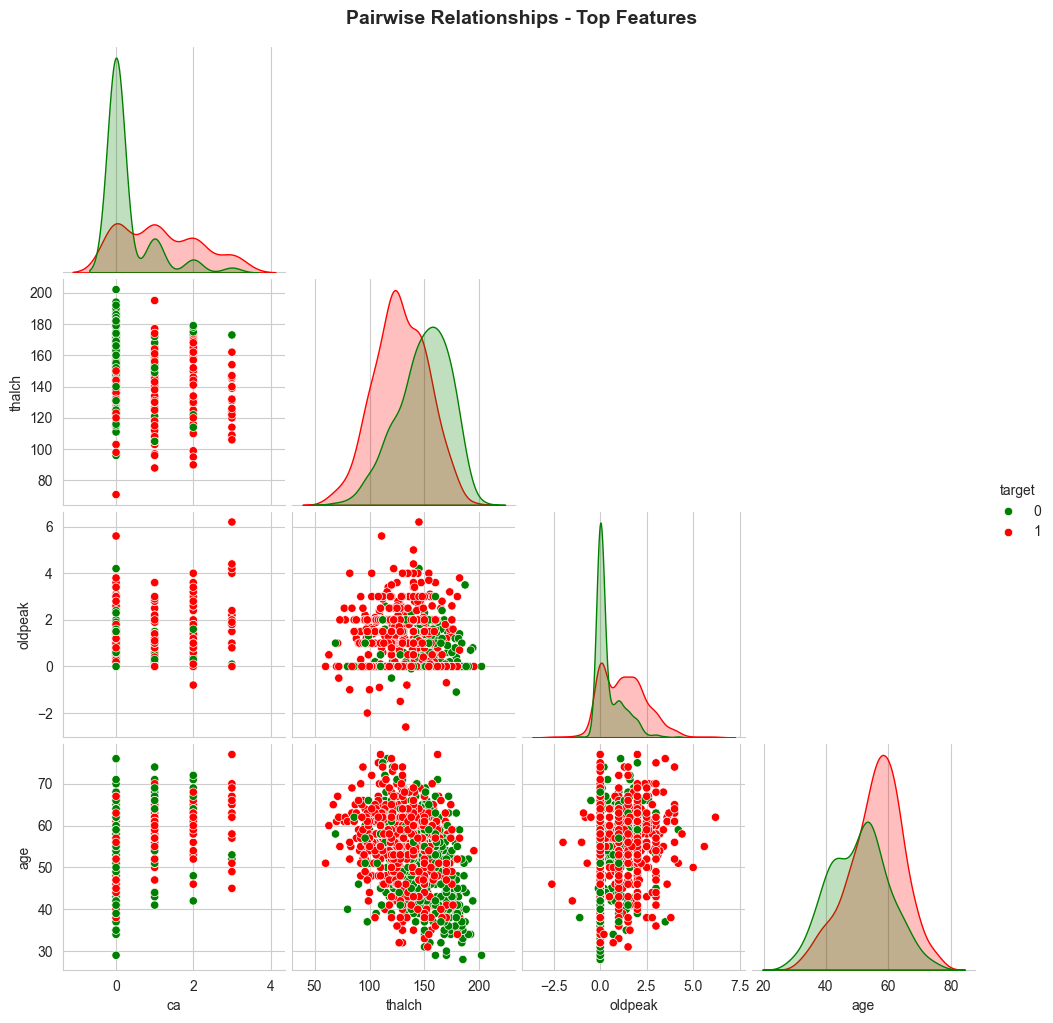

In [31]:
# Select top correlated features with target for scatter plots
top_features = target_corr.abs().nlargest(4).index.tolist()

if len(top_features) >= 2:
    # Create pairplot for top features
    sns.pairplot(df[top_features + ['target']], hue='target', 
                palette={0: 'green', 1: 'red'}, diag_kind='kde', corner=True)
    plt.suptitle('Pairwise Relationships - Top Features', y=1.02, fontsize=14, fontweight='bold')
    plt.show()

## 14. Key Findings & Recommendations

In [29]:
print("="*70)
print("EDA SUMMARY - KEY FINDINGS")
print("="*70)

print("\n1. DATASET OVERVIEW:")
print(f"   - Total samples: {df.shape[0]}")
print(f"   - Total features: {df.shape[1]}")
print(f"   - Disease prevalence: {df['target'].mean()*100:.1f}%")

print("\n2. DATA QUALITY ISSUES:")
high_missing = missing_data[missing_data['Missing_Percentage'] > 30]
if len(high_missing) > 0:
    print(f"   - Features with >30% missing data: {', '.join(high_missing.index.tolist())}")
print("   - Suspicious zero values likely representing missing data in: trestbps, chol")
print("   - Invalid negative values in: oldpeak")

print("\n3. STRONGEST PREDICTORS (by correlation):")
for i, (feat, corr) in enumerate(target_corr.head(5).items(), 1):
    print(f"   {i}. {feat}: {corr:.3f}")

print("\n4. RECOMMENDED PREPROCESSING STEPS:")
print("   ✓ Convert zero values to NaN for: trestbps, chol, thalch")
print("   ✓ Handle negative oldpeak values")
print("   ✓ Decide imputation strategy for high-missing features (ca, thal, slope)")
print("   ✓ Encode categorical variables (sex, cp, fbs, restecg, exang, slope, thal)")
print("   ✓ Scale numerical features for modeling")
print("   ✓ Consider outlier treatment based on domain knowledge")

print("\n5. NEXT STEPS:")
print("   → Feature engineering (interactions, binning)")
print("   → Handle class imbalance if necessary")
print("   → Feature selection based on importance")
print("   → Model training and validation")
print("\n" + "="*70)

EDA SUMMARY - KEY FINDINGS

1. DATASET OVERVIEW:
   - Total samples: 920
   - Total features: 17
   - Disease prevalence: 55.3%

2. DATA QUALITY ISSUES:
   - Features with >30% missing data: ca, thal, slope
   - Suspicious zero values likely representing missing data in: trestbps, chol
   - Invalid negative values in: oldpeak

3. STRONGEST PREDICTORS (by correlation):
   1. ca: 0.456
   2. oldpeak: 0.386
   3. age: 0.283
   4. trestbps: 0.106
   5. chol: -0.231

4. RECOMMENDED PREPROCESSING STEPS:
   ✓ Convert zero values to NaN for: trestbps, chol, thalch
   ✓ Handle negative oldpeak values
   ✓ Decide imputation strategy for high-missing features (ca, thal, slope)
   ✓ Encode categorical variables (sex, cp, fbs, restecg, exang, slope, thal)
   ✓ Scale numerical features for modeling
   ✓ Consider outlier treatment based on domain knowledge

5. NEXT STEPS:
   → Feature engineering (interactions, binning)
   → Handle class imbalance if necessary
   → Feature selection based on importan

## 15. Export Cleaned Insights

In [30]:
# Save key statistics to CSV for reference
summary_stats = df.describe().T
summary_stats['missing_%'] = (df.isnull().sum() / len(df) * 100).values
summary_stats['target_correlation'] = correlation_matrix['target'].values

# Uncomment to save:
# summary_stats.to_csv('../output/eda_summary_statistics.csv')
# print("Summary statistics saved to: ../output/eda_summary_statistics.csv")

summary_stats

ValueError: Length of values (17) does not match length of index (9)

---
## End of EDA
This comprehensive analysis provides a solid foundation for preprocessing and model development.